# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


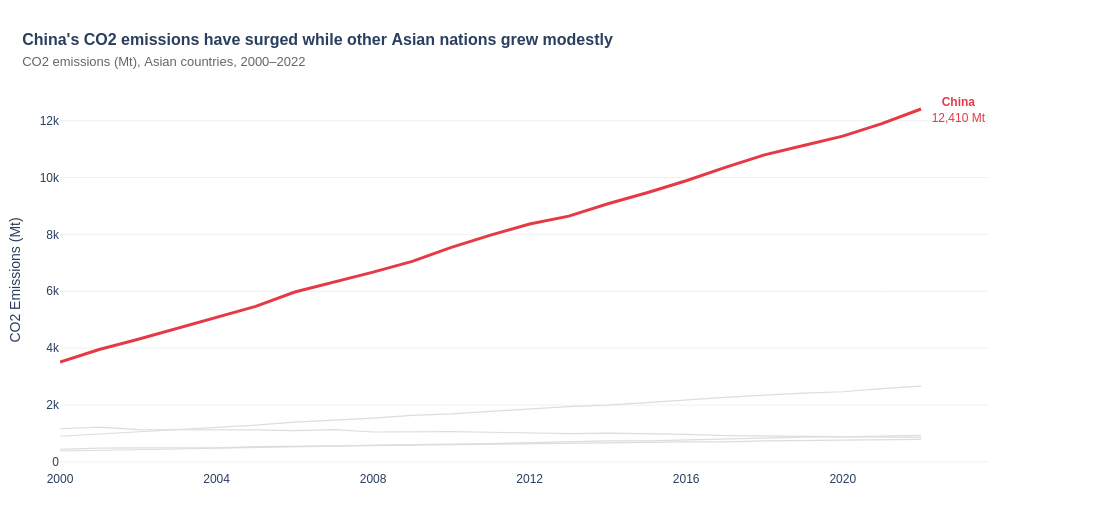

In [3]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE

# Filter to Asia
asia_df = df[df['Region'] == 'Asia'].copy()
highlight = 'China'

fig = go.Figure()

# Loop: grey lines first (background), then highlighted on top
for country in asia_df['Country'].unique():
    country_df = asia_df[asia_df['Country'] == country].sort_values('Year')
    is_highlight = country == highlight

    fig.add_trace(go.Scatter(
        x=country_df['Year'],
        y=country_df['CO2_Mt'],
        mode='lines',
        name=country,
        line=dict(
            color='#E63946' if is_highlight else '#DDDDDD',
            width=3 if is_highlight else 1.2,
        ),
        showlegend=False,
        hovertemplate=f'<b>{country}</b><br>Year: %{{x}}<br>CO2: %{{y:.0f}} Mt<extra></extra>'
            if is_highlight else
            f'{country}: %{{y:.0f}} Mt<extra></extra>',
        zorder=10 if is_highlight else 1,
    ))

# Direct end-of-line label for China
china_last = asia_df[asia_df['Country'] == highlight].sort_values('Year').iloc[-1]

fig.add_annotation(
    x=china_last['Year'],
    y=china_last['CO2_Mt'],
    text=f"<b>{highlight}</b><br>{china_last['CO2_Mt']:,.0f} Mt",
    xanchor='left',
    xshift=8,
    showarrow=False,
    font=dict(color='#E63946', size=12),
)

fig.update_layout(
    title=dict(
        text="<b>China's CO2 emissions have surged while other Asian nations grew modestly</b><br>"
             "<span style='font-size:13px;color:#666'>CO2 emissions (Mt), Asian countries, 2000–2022</span>",
        x=0.02,
        xanchor='left',
        font=dict(size=16),
    ),
    xaxis=dict(
        title=None,
        showgrid=False,
        tickmode='linear',
        dtick=4,
    ),
    yaxis=dict(
        title='CO2 Emissions (Mt)',
        showgrid=True,
        gridcolor='#F0F0F0',
        zeroline=False,
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=120, t=90, b=50),
    hovermode='x unified',
    width=900,
    height=520,
)

fig.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


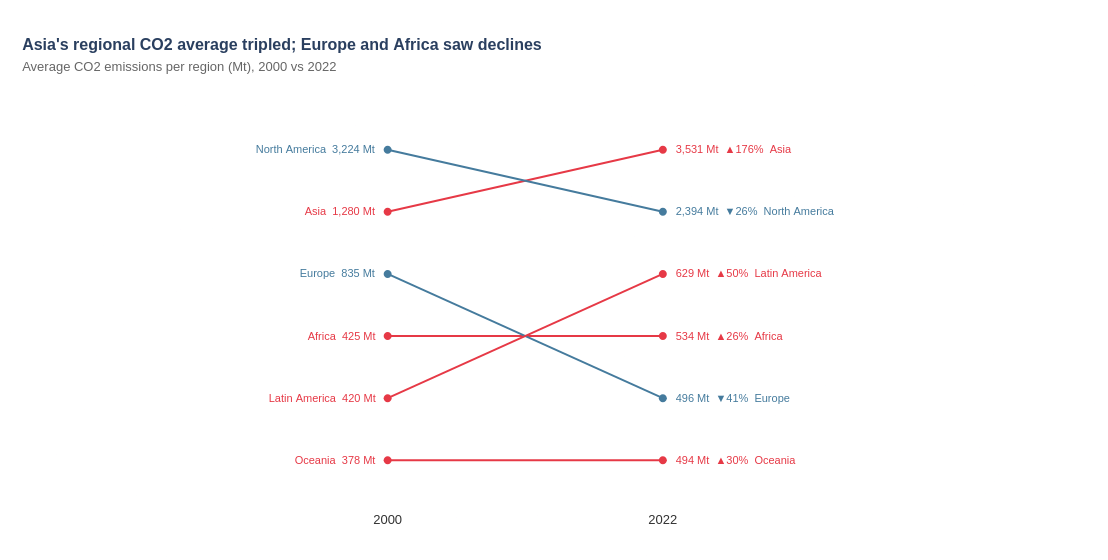

In [5]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE

# Aggregate
regional = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()
r2000 = regional[regional['Year'] == 2000].set_index('Region')['CO2_Mt']
r2022 = regional[regional['Year'] == 2022].set_index('Region')['CO2_Mt']

regions = r2000.index.tolist()

COLOR_UP = '#E63946'
COLOR_DOWN = '#457B9D'

# Assign evenly spaced y-positions sorted by 2000 value
sorted_by_2000 = r2000.sort_values().index.tolist()
sorted_by_2022 = r2022.sort_values().index.tolist()

n = len(regions)
y_positions_2000 = {region: i for i, region in enumerate(sorted_by_2000)}
y_positions_2022 = {region: i for i, region in enumerate(sorted_by_2022)}

fig = go.Figure()

for region in regions:
    val_2000 = r2000[region]
    val_2022 = r2022[region]
    increased = val_2022 > val_2000
    color = COLOR_UP if increased else COLOR_DOWN
    pct_change = ((val_2022 - val_2000) / val_2000) * 100
    arrow = '▲' if increased else '▼'

    y0 = y_positions_2000[region]
    y1 = y_positions_2022[region]

    # Line
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[y0, y1],
        mode='lines',
        line=dict(color=color, width=2),
        showlegend=False,
        hovertemplate=f'<b>{region}</b><br>2000: {val_2000:,.0f} Mt → 2022: {val_2022:,.0f} Mt<extra></extra>',
    ))

    # Dots
    fig.add_trace(go.Scatter(
        x=[2000, 2022], y=[y0, y1],
        mode='markers',
        marker=dict(color=color, size=8),
        showlegend=False,
        hoverinfo='skip',
    ))

    # Left label
    fig.add_annotation(
        x=2000, y=y0,
        text=f"{region}  {val_2000:,.0f} Mt",
        xanchor='right', xshift=-10,
        showarrow=False,
        font=dict(color=color, size=11),
    )

    # Right label
    fig.add_annotation(
        x=2022, y=y1,
        text=f"{val_2022:,.0f} Mt  {arrow}{abs(pct_change):.0f}%  {region}",
        xanchor='left', xshift=10,
        showarrow=False,
        font=dict(color=color, size=11),
    )

fig.update_layout(
    title=dict(
        text="<b>Asia's regional CO2 average tripled; Europe and Africa saw declines</b><br>"
             "<span style='font-size:13px;color:#666'>Average CO2 emissions per region (Mt), 2000 vs 2022</span>",
        x=0.02, xanchor='left',
        font=dict(size=16),
    ),
    xaxis=dict(
        tickvals=[2000, 2022],
        ticktext=['2000', '2022'],
        tickfont=dict(size=13, color='#333'),
        showgrid=False,
        zeroline=False,
        range=[1985, 2040],
    ),
    yaxis=dict(
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        range=[-0.8, n - 0.2],
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=200, r=220, t=100, b=50),
    width=950,
    height=560,
)

fig.show()